# Критерії випадковості та сезонності часових рядів

In [2]:
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional

import numpy as np
import polars as pl
from scipy.stats import linregress, norm
from statsmodels.graphics.tsaplots import plot_acf

STAND_QUANT = norm.ppf(0.95)

In [3]:
STAND_QUANT

np.float64(1.6448536269514722)

In [4]:
@dataclass
class TimeSeries:
    file_path: str
    series_col_name: str
    time_col_name: str
    time_format: str
    dataset: Optional[pl.DataFrame] = None

    def __post_init__(self):
        self.dataset = self._load_time_series()

    @property
    def series(self) -> pl.Series:
        return self.dataset[self.series_col_name]

    @property
    def times(self) -> pl.Series:
        return self.dataset[self.time_col_name]

    def _load_time_series(self) -> pl.DataFrame:
        if self.file_path.endswith('.csv'):
            return (
                pl.read_csv(self.file_path, try_parse_dates=True)
                .with_columns(pl.col(self.time_col_name).str.to_datetime(self.time_format))
                .sort(self.time_col_name)
            )
        raise TypeError(f"Unexpected file format: {self.file_path.split('.')[-1]}.")

    @staticmethod
    def check_for_randomness(stat_value: int):
        if abs(stat_value) <= STAND_QUANT:
            print("Часовий ряд ВИПАДКОВИЙ")
        else:
            print("Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.")

    def plot_series(self) -> None:
        plt.plot(self.times, self.series)
        plt.xlabel("Times")
        plt.ylabel("Series")
        plt.grid(True)
        plt.show()

    def plot_acf(self, lags: Optional[int] = None) -> None:
        if lags is None:
            lags = len(self.series) - 1
        plot_acf(self.series, lags=lags)
        plt.title("Корелограма")
        plt.show()

    def sign_test(self, series: Optional[pl.Series] = None) -> float:
        if series is None:
            series = self.series

        signs = np.sign(np.diff(series))
        signs = signs[signs != 0]

        c = np.sum(signs[1:] != signs[:-1])
        n = len(signs)
        expected = (n - 1) / 2
        variance = (n + 1) / 12

        return (c - expected) / np.sqrt(variance)

    def record_test(self, with_plot: bool = True) -> tuple[float, float]:
        positive_records = []
        negative_records = []

        max_value = self.series[0]
        min_value = self.series[0]

        for idx in range(1, len(self.series)):
            value = self.series[idx]
            if self.series[idx] > max_value and self.series[idx - 1] <= value >= self.series[idx + 1]:
                positive_records.append((idx, value))
                max_value = value

            if value < min_value and self.series[idx - 1] >= value <= self.series[idx + 1]:
                negative_records.append((idx, value))
                min_value = value

        l = len(negative_records)
        m = len(positive_records)
        n = len(time_series.series)
        d = m - l
        s = m + l

        d_d = sum(2 / i for i in range(2, n + 1))
        d_s = sum((2 / i) - (4 / pow(i, 2)) for i in range(2, n + 1))
        stat_1 = d / np.sqrt(d_d)
        stat_2 = (s - d_d) / np.sqrt(d_s)
        if with_plot:
            plt.plot(time_series.series, label='Часовий ряд')
            plt.scatter(*zip(*positive_records), color='g', label='Позитивні рекорди', zorder=2, s=10)
            plt.scatter(*zip(*negative_records), color='r', label='Негативні рекорди', zorder=2, s=10)
            plt.legend()
            plt.title("Рекордні значення в часому ряді")
            plt.show()
        return stat_1, stat_2

    def remove_linear_trend(self, with_plot: bool = True) -> np.ndarray:
        y = self.series.to_numpy()
        x = np.arange(len(y))
        slope, intercept, *_ = linregress(x, y)
        trend = intercept + slope * x
        residuals = y - trend
        if with_plot:
            plt.plot(residuals)
            plt.title("Залишки після видалення тренду")
            plt.grid(True)
            plt.show()
        return residuals

In [5]:
time_series = TimeSeries(
    file_path='./data/AirPassengers.csv',
    series_col_name='Passengers',
    time_col_name='Month',
    time_format='%Y-%m'
)
# time_series = TimeSeries(
#     file_path='./data/MLTollsStackOverflow.csv',
#     series_col_name='python',
#     time_col_name='month',
#     time_format='%y-%b'
# )
time_series.dataset

Month,Passengers
datetime[μs],i64
1949-01-01 00:00:00,112
1949-02-01 00:00:00,118
1949-03-01 00:00:00,132
1949-04-01 00:00:00,129
1949-05-01 00:00:00,121
…,…
1960-08-01 00:00:00,606
1960-09-01 00:00:00,508
1960-10-01 00:00:00,461


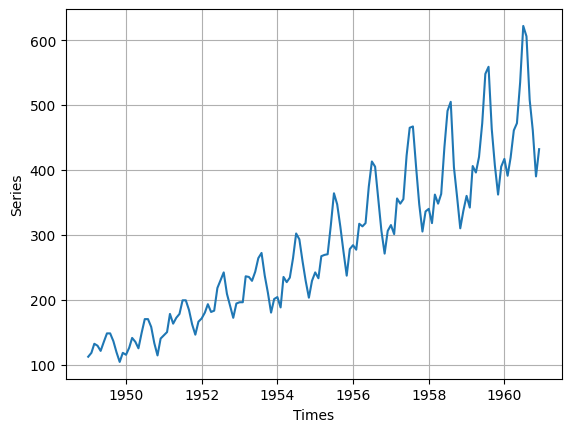

In [6]:
time_series.plot_series()

### Метод знаків

In [7]:
K = time_series.sign_test()
print(f"K-статистика = {K}")
time_series.check_for_randomness(stat_value=K)

K-статистика = -2.6349301969610397
Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.


### Метод рекордних значень

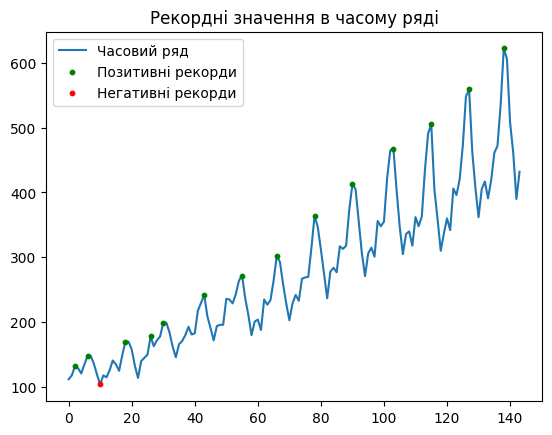

T1-статистика = 4.309222613908991
T2-статистика = 2.305118838730189
Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.


In [8]:
stats = time_series.record_test()
print(f"T1-статистика = {stats[0]}")
print(f"T2-статистика = {stats[1]}")
time_series.check_for_randomness(stat_value=stats[0])

### Корелограма

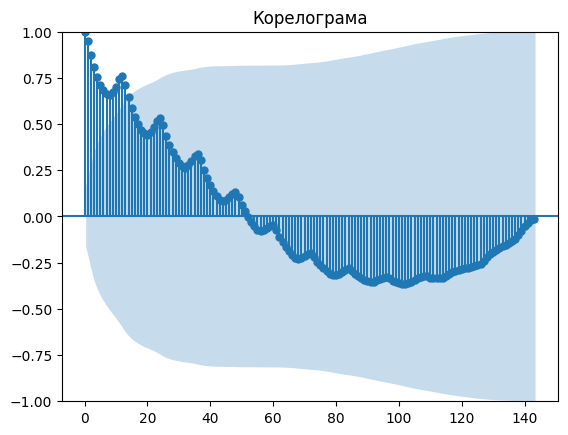

In [9]:
time_series.plot_acf()

### Видалення тренду

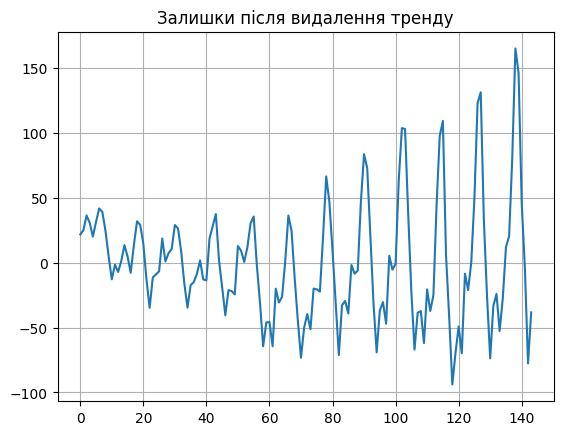

K-статистика = -2.0207259421636903
Часовий ряд НЕ ВИПАДКОВИЙ. Наявний певний тренд.


In [10]:
residuals = time_series.remove_linear_trend()
K = time_series.sign_test(residuals)
print(f"K-статистика = {K}")
time_series.check_for_randomness(stat_value=K)